# 08 · Bake-off summary — which representation recovers which typology

This notebook assembles the headline grid (see `RESULTS.md`). It:

1. computes the **tabular GLM** reference for all five typologies (isolated solo-vs-legit AUC)
   plus the multi-label view;
2. loads the **ring** (notebook 06) and **temporal** (notebook 07) structural-oracle,
   learned-neural, and LR-gate results;
3. renders the full grid + the tabular → learned → oracle comparison.

> Run notebooks **06** and **07** first — this notebook reads their saved
> `data/processed/{ring,temporal}_results.json`.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, "..")
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

from src.features import build_features
from src.inject import typology_dummies, is_cross_border, TYPOLOGY_COL, TYPOLOGIES
from src.evaluation import multi_label_report


def load(split):
    df = pd.read_parquet(f"../data/processed/injected_{split}.parquet")
    df["trans_dt"] = pd.to_datetime(df["trans_date_trans_time"])
    return df


tr, te = load("train"), load("test")

## [1] Tabular GLM reference grid

One L2-logistic per typology over the full tabular design matrix, scored on isolated solo rows (the honest 'can a table row reveal this signature?' line).

In [2]:
Xtr = build_features(tr)
Xte = build_features(te).reindex(columns=Xtr.columns, fill_value=0.0)
Ytr = typology_dummies(tr)[TYPOLOGIES]
Yte = typology_dummies(te)[TYPOLOGIES]

scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

typ_te = te[TYPOLOGY_COL].fillna("").to_numpy()
legit = typ_te == ""
scores = np.zeros((len(te), len(TYPOLOGIES)))
tabular_auc = {}
for i, typ in enumerate(TYPOLOGIES):
    clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf.fit(Xtr_s, Ytr[typ].to_numpy())
    scores[:, i] = clf.predict_proba(Xte_s)[:, 1]
    solo = typ_te == typ
    mask = solo | legit
    tabular_auc[typ] = roc_auc_score(solo[mask].astype(int), scores[mask, i])

print(f"[{Xtr.shape[1]} tabular features]  isolated AUC (solo vs legit):")
for typ in TYPOLOGIES:
    print(f"  {typ:9s} {tabular_auc[typ]:.3f}")

preds = (scores >= 0.5).astype(int)
rep = multi_label_report(Yte.to_numpy(), preds, scores, label_names=TYPOLOGIES)
cb = int(is_cross_border(te).sum())
print(f"\nmulti-label view (incl. overlaps): mean_auc={rep['mean_auc']:.3f}  "
      f"LRAP={rep['label_ranking_ap']:.3f}  cross_border test rows={cb:,}")

Z:\Projects\2026\cross-border-credit\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[78 tabular features]  isolated AUC (solo vs legit):
  ring      0.582
  velocity  0.882
  temporal  0.702
  category  0.874
  geo       1.000



multi-label view (incl. overlaps): mean_auc=0.862  LRAP=0.997  cross_border test rows=2,408


## [2] Load the neural-slot results (notebooks 06 & 07)

In [3]:
proc = Path("../data/processed")
missing = [p.name for p in (proc / "ring_results.json", proc / "temporal_results.json") if not p.exists()]
if missing:
    raise FileNotFoundError(f"Missing {missing} — run notebooks 06 and 07 first.")
ring = json.load(open(proc / "ring_results.json"))
temporal = json.load(open(proc / "temporal_results.json"))
ring, temporal

({'typology': 'ring',
  'tabular': 0.582,
  'learned_ringsage': 0.8409783256780751,
  'oracle_fanin_cards': 0.9585628265408688,
  'oracle_fanin_txns': 0.9582388332471702,
  'lr_G2': 9731.620165249988,
  'lr_df': 2,
  'lr_p': 0.0,
  'lr_admitted': True},
 {'typology': 'temporal',
  'tabular': 0.702,
  'learned_temporalssm': 0.8056324395528389,
  'oracle_hour_rarity': 0.8772228556909809,
  'lr_G2': 12246.79626220349,
  'lr_df': 2,
  'lr_p': 0.0,
  'lr_admitted': True})

## [3] The bake-off grid

In [4]:
def fmt_gate(r):
    if not np.isfinite(r["lr_G2"]):
        return "separates -> admitted"
    return f"admitted G2={r['lr_G2']:.0f} (df {r['lr_df']}, p~0)" if r["lr_admitted"] else "dropped"

grid = pd.DataFrame([
    {"typology": "ring", "tabular GLM": tabular_auc["ring"],
     "structural oracle": ring["oracle_fanin_cards"], "learned neural": ring["learned_ringsage"],
     "LR-test gate": fmt_gate(ring)},
    {"typology": "temporal", "tabular GLM": tabular_auc["temporal"],
     "structural oracle": temporal["oracle_hour_rarity"], "learned neural": temporal["learned_temporalssm"],
     "LR-test gate": fmt_gate(temporal)},
    {"typology": "velocity", "tabular GLM": tabular_auc["velocity"],
     "structural oracle": np.nan, "learned neural": np.nan, "LR-test gate": "tabular-solved"},
    {"typology": "category", "tabular GLM": tabular_auc["category"],
     "structural oracle": np.nan, "learned neural": np.nan, "LR-test gate": "tabular"},
    {"typology": "geo", "tabular GLM": tabular_auc["geo"],
     "structural oracle": np.nan, "learned neural": np.nan, "LR-test gate": "tabular-solved (null control)"},
]).set_index("typology")
grid.round(3)

,tabular GLM,structural oracle,learned neural,LR-test gate
typology,,,,
ring,0.582,0.959,0.841,"admitted G2=9732 (df 2, p~0)"
temporal,0.702,0.877,0.806,"admitted G2=12247 (df 2, p~0)"
velocity,0.882,NaN,NaN,tabular-solved
category,0.874,NaN,NaN,tabular
geo,1.000,NaN,NaN,tabular-solved (null control)


## [4] Where neural earns its place — tabular → learned → oracle

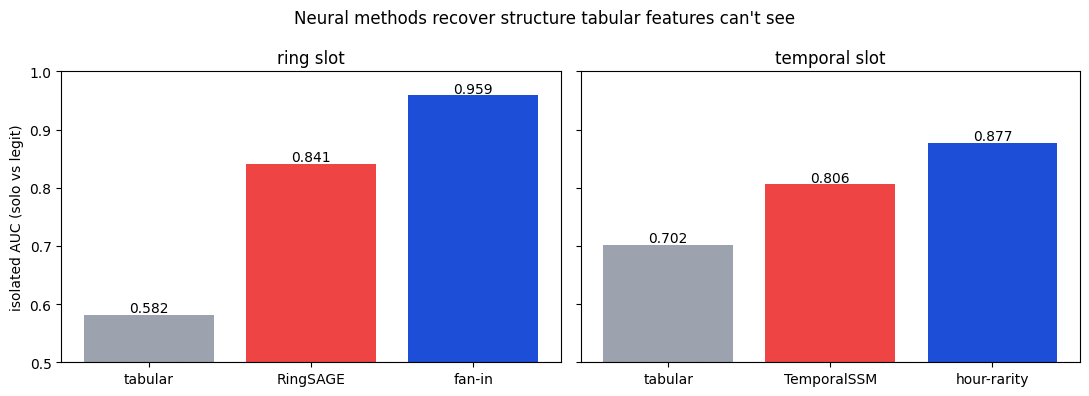

In [5]:
slots = {
    "ring": (ring["tabular"], ring["learned_ringsage"], ring["oracle_fanin_cards"],
             "RingSAGE", "fan-in"),
    "temporal": (temporal["tabular"], temporal["learned_temporalssm"], temporal["oracle_hour_rarity"],
                 "TemporalSSM", "hour-rarity"),
}
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (name, (tab, learned, oracle, lname, oname)) in zip(axes, slots.items()):
    bars = ax.bar(["tabular", lname, oname], [tab, learned, oracle],
                  color=["#9ca3af", "#ef4444", "#1d4ed8"])
    ax.set_ylim(0.5, 1.0); ax.set_title(f"{name} slot"); ax.axhline(0.5, color="k", lw=0.8, ls=":")
    for b, v in zip(bars, [tab, learned, oracle]):
        ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}", ha="center")
axes[0].set_ylabel("isolated AUC (solo vs legit)")
fig.suptitle("Neural methods recover structure tabular features can't see")
plt.tight_layout(); plt.show()

## Reading

`ring` and `temporal` are the two signatures invisible to a single table row — a ring is a
*time-windowed* merchant fan-in (tabular ≈ chance), a temporal anomaly is *card-relative*
(global hour features top out at 0.70). In both, the learned model sits **between tabular and
the hand-crafted oracle** and clears the LR-test gate. `geo`/`velocity`/`category` stay
tabular by design; `geo` is the null-LR-test negative control.

> **Sparkov caveat.** The simulator's fraud is cleaner and more separable than real
> production traffic (`geo` separating perfectly is a symptom). This benchmark answers
> *"which representation recovers which structure,"* **not** *"production-grade fraud
> detection."* See `RESULTS.md` for the full writeup.